In [7]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import sys
import importlib

In [8]:
# Get the path of the notebook file
notebook_path = os.getcwd()

# Directory containing the notebook file
notebook_directory = os.path.dirname(notebook_path)
notebook_directory

'/Users/himanshuyadav/UF Dropbox/Himanshu Yadav/files/PhD_TDA/Climate'

In [9]:
sys.path.append(os.path.join(notebook_directory, 'src'))
import cubical_pers_and_filt_visual, globe_visualization, feature_tracking

importlib.reload(cubical_pers_and_filt_visual)
importlib.reload(globe_visualization)
importlib.reload(feature_tracking)

<module 'feature_tracking' from '/Users/himanshuyadav/UF Dropbox/Himanshu Yadav/files/PhD_TDA/Climate/src/feature_tracking.py'>

# Visulalization

In [10]:
# Load specific year and day
df = feature_tracking.load_all_representative_data_to_df(years=1948, days=1,notebook_dir=notebook_directory)
df

,year,day,data_type,feature_index,birth,death,persistence,representative,death_simplex_vertices
0,1948,1,sub,61,-54.341457,1685.783813,1740.125271,"[[[64, 74], [65, 74]], [[65, 74], [66, 74]], [...","[[105, 123], [106, 123], [105, 124], [106, 124]]"
1,1948,1,sub,60,207.378220,1677.995850,1470.617630,"[[[53, 7], [53, 8]], [[52, 8], [53, 8]], [[145...","[[83, 18], [84, 18], [83, 19], [84, 19]]"
2,1948,1,sub,59,139.274673,1246.956787,1107.682114,"[[[88, 109], [88, 110]], [[88, 110], [88, 111]...","[[64, 108], [65, 108], [64, 109], [65, 109]]"
3,1948,1,sub,58,-33.940052,504.925354,538.865406,"[[[111, 85], [112, 85]], [[112, 85], [113, 85]...","[[118, 72], [119, 72], [118, 73], [119, 73]]"
4,1948,1,sub,57,108.889824,624.874939,515.985115,"[[[46, 60], [46, 61]], [[46, 61], [46, 62]], [...","[[57, 56], [58, 56], [57, 57], [58, 57]]"
...,...,...,...,...,...,...,...,...,...
134,1948,1,sup,4,151.073303,151.747147,0.673843,"[[[74, 74], [75, 74]], [[75, 74], [76, 74]], [...","[[75, 72], [76, 72], [75, 73], [76, 73]]"
135,1948,1,sup,3,294.944153,295.232025,0.287872,"[[[134, 142], [135, 142]], [[135, 142], [136, ...","[[135, 140], [136, 140], [135, 141], [136, 141]]"
136,1948,1,sup,2,385.278778,385.528870,0.250092,"[[[102, 153], [102, 154]], [[102, 154], [103, ...","[[102, 152], [103, 152], [102, 153], [103, 153]]"
137,1948,1,sup,1,638.267822,638.491516,0.223694,"[[[26, 103], [27, 103]], [[27, 103], [28, 103]...","[[25, 101], [26, 101], [25, 102], [26, 102]]"


# Area calculation

In [11]:
df['area_km2'] = df['representative'].apply(
    lambda rep: feature_tracking.compute_representative_area_km2(
        rep,
        matrix_size=172,
        lat_range=(0, 90),
        lon_range=(0, 360)
    )
)

df[['year', 'day', 'data_type', 'feature_index', 'persistence', 'area_km2']]

,year,day,data_type,feature_index,persistence,area_km2
0,1948,1,sub,61,1740.125271,2.220097e+07
1,1948,1,sub,60,1470.617630,7.502684e+07
2,1948,1,sub,59,1107.682114,2.201304e+07
3,1948,1,sub,58,538.865406,3.039403e+06
4,1948,1,sub,57,515.985115,5.397472e+06
...,...,...,...,...,...,...
134,1948,1,sup,4,0.673843,8.071039e+04
135,1948,1,sup,3,0.287872,9.263610e+04
136,1948,1,sup,2,0.250092,4.082526e+04
137,1948,1,sup,1,0.223694,5.967914e+04


# Area Time Series Analysis

In [ ]:
import pickle

area_dir = os.path.join(notebook_directory, 'data', 'processed_data', 'area_data')
os.makedirs(area_dir, exist_ok=True)

sub_path = os.path.join(area_dir, 'area_sub_1948_2023.pkl')
sup_path = os.path.join(area_dir, 'area_sup_1948_2023.pkl')

if os.path.exists(sub_path):
    with open(sub_path, 'rb') as f:
        area_sub = pickle.load(f)
    print("Loaded cached sub area data")
else:
    area_sub = feature_tracking.get_area_by_year_day('sub', notebook_directory, 1948, 2023)
    with open(sub_path, 'wb') as f:
        pickle.dump(area_sub, f)
    print("Saved sub area cache")

if os.path.exists(sup_path):
    with open(sup_path, 'rb') as f:
        area_sup = pickle.load(f)
    print("Loaded cached sup area data")
else:
    area_sup = feature_tracking.get_area_by_year_day('sup', notebook_directory, 1948, 2023)
    with open(sup_path, 'wb') as f:
        pickle.dump(area_sup, f)
    print("Saved sup area cache")

Computing sup area data for years 1948-2023


Computing sup area: 100%|██████████| 76/76 [17:29<00:00, 13.81s/it]

Area dictionary created for 76 years
Saved sup area cache


In [15]:
# Build daily time series with a 365-day calendar (matching TDA data — no Feb 29)
days_in_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
month_of_doy, day_of_doy = [], []
for m, nd in enumerate(days_in_month, 1):
    for d in range(1, nd + 1):
        month_of_doy.append(m)
        day_of_doy.append(d)

dates, sub_vals, sup_vals = [], [], []
for year in range(1948, 2024):
    for doy in range(365):
        dates.append(pd.Timestamp(year=year, month=month_of_doy[doy], day=day_of_doy[doy]))
        sub_vals.append(area_sub[year][doy])
        sup_vals.append(area_sup[year][doy])

area_df_daily = pd.DataFrame({
    'sub_total_area': sub_vals,
    'sup_total_area': sup_vals,
}, index=pd.DatetimeIndex(dates))

area_df_daily

,sub_total_area,sup_total_area
1948-01-01,1.476159e+08,1.254061e+08
1948-01-02,9.068000e+07,6.993096e+07
1948-01-03,6.329086e+07,6.818896e+07
1948-01-04,1.135255e+08,7.287611e+07
1948-01-05,1.079042e+08,7.614369e+07
...,...,...
2023-12-27,6.504189e+07,2.677331e+08
2023-12-28,1.519233e+08,1.305064e+08
2023-12-29,1.074557e+08,3.238518e+08
2023-12-30,6.358862e+07,1.232902e+08


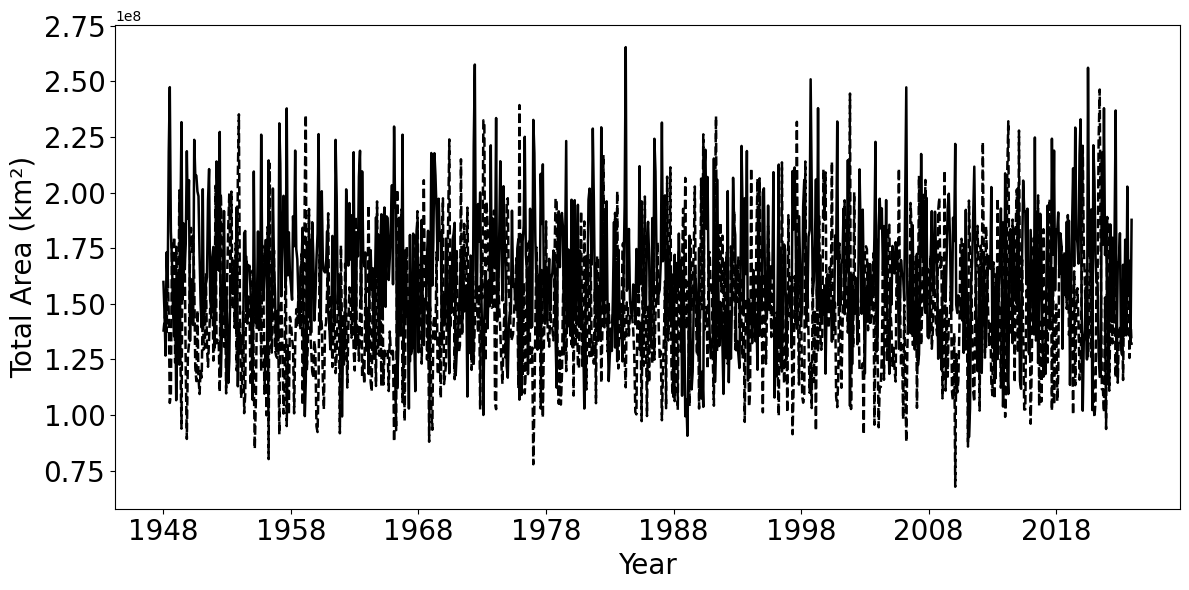

In [16]:
# Monthly average (same as notebook 03)
monthly_area_df = area_df_daily[['sub_total_area', 'sup_total_area']].resample('MS').mean()

def plot_two_columns_area(df, col1, col2, figsize=(12, 6),
                          label_fontsize=12, tick_fontsize=10,
                          ylabel='Total Area (km²)', year_step=10,
                          label1=r'TAM$_A$', label2=r'TAM$_C$'):
    plt.figure(figsize=figsize)
    plt.plot(df.index, df[col2], color='black', linestyle='-',  linewidth=1.8, label=label2)
    plt.plot(df.index, df[col1], color='black', linestyle='--', linewidth=1.8, label=label1)
    plt.xlabel("Year", fontsize=label_fontsize)
    plt.ylabel(ylabel, fontsize=label_fontsize)
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)
    plt.grid(False)
    years = sorted(df.index.year.unique())
    selected = years[::year_step]
    positions = [df.index[df.index.year == y][0] for y in selected]
    plt.xticks(positions, [str(y) for y in selected], fontsize=tick_fontsize)
    plt.tight_layout()
    return plt

fig_dir = os.path.join(notebook_directory, 'output', 'figures')
os.makedirs(fig_dir, exist_ok=True)

plot_two_columns_area(
    monthly_area_df,
    'sub_total_area', 'sup_total_area',
    label_fontsize=20, tick_fontsize=20, year_step=10,
)
plt.savefig(os.path.join(fig_dir, 'area_average_monthly.png'), dpi=300, bbox_inches='tight')
plt.show()

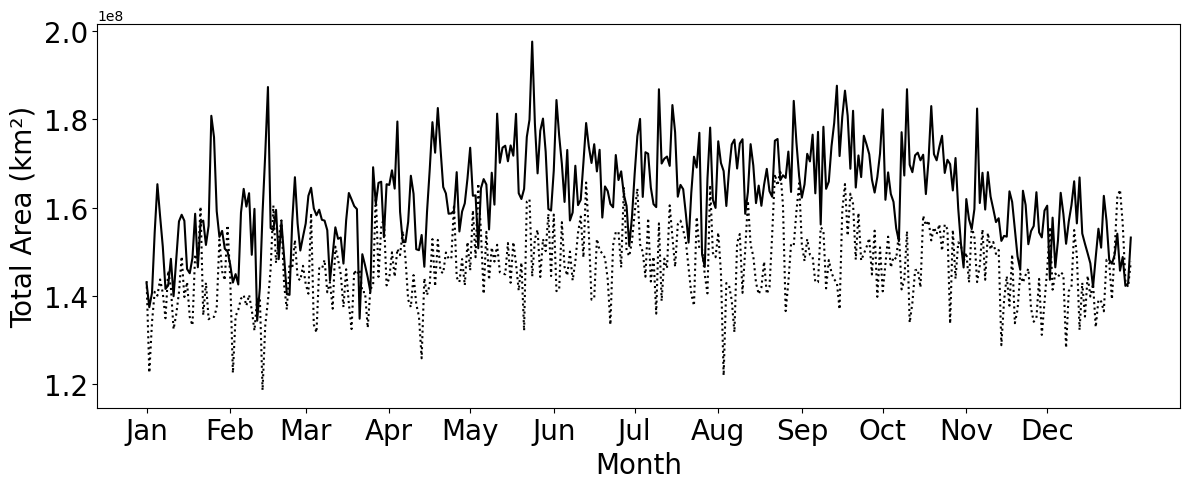

In [17]:
# Day-of-year average (same as notebook 03)
doy_area = area_df_daily[['sub_total_area', 'sup_total_area']].copy()
doy_area['doy'] = doy_area.index.dayofyear
doy_mean_area = doy_area.groupby('doy').mean()

month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels  = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(doy_mean_area.index, doy_mean_area['sup_total_area'],
        color='black', linestyle='-',  linewidth=1.5, label=r'TAD$_C$ average')
ax.plot(doy_mean_area.index, doy_mean_area['sub_total_area'],
        color='black', linestyle=':',  linewidth=1.5, label=r'TAD$_A$ average')

fs = 20
ax.set_xticks(month_starts)
ax.set_xticklabels(month_labels, fontsize=fs)
ax.set_xlabel('Month', fontsize=fs)
ax.set_ylabel('Total Area (km²)', fontsize=fs)
ax.tick_params(axis='y', labelsize=fs)
ax.grid(False)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'area_average.png'), dpi=300, bbox_inches='tight')
plt.show()